In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
train_meta = pd.read_csv("train_metadata.csv")

<Axes: xlabel='label'>

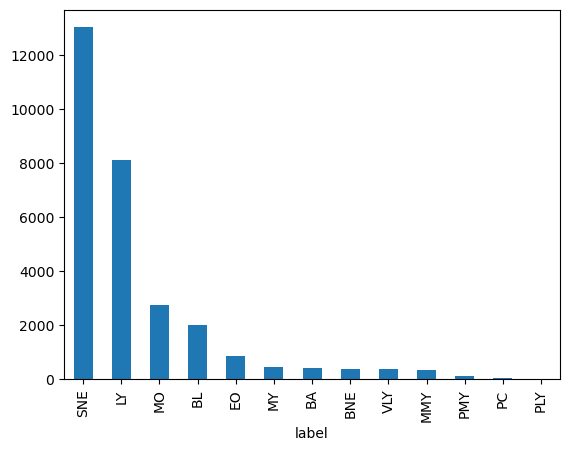

In [8]:
train_meta.value_counts("label").plot(kind="bar")

## Build models on extracted features and validation results

In [ ]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ======================
# LOAD FEATURES
# ======================

X_train = np.load("train_features_resnet_wbc_augmented_best.npy")
X_val   = np.load("val_features_resnet_wbc_augmented_best.npy")

# ======================
# LOAD LABELS FROM CSV
# ======================

train_df = pd.read_csv("train_split.csv")
val_df   = pd.read_csv("val_split.csv")

# Change "label" if your column has another name
y_train = train_df["label"].values
y_val   = val_df["label"].values

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Train labels shape:", y_train.shape)
print("Val labels shape:", y_val.shape)

# ======================
# SVM PIPELINE
# ======================

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),  # keep 95% variance
    ("svm", SVC(
        kernel="linear",
        class_weight="balanced"
    ))
])

svm_pipeline.fit(X_train, y_train)

y_pred_svm = svm_pipeline.predict(X_val)

print("\n=== SVM Results (Validation) ===")
print("Accuracy:", accuracy_score(y_val, y_pred_svm))
print("Macro-F1:", f1_score(y_val, y_pred_svm, average="macro"))
print(classification_report(y_val, y_pred_svm))

# ======================
# 2QDA PIPELINE
# ======================

qda_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),  # keep 95% variance
    ("qda", QuadraticDiscriminantAnalysis(reg_param=0.1))
])

qda_pipeline.fit(X_train, y_train)

y_pred_qda = qda_pipeline.predict(X_val)

print("\n=== QDA Results (Validation) ===")
print("Accuracy:", accuracy_score(y_val, y_pred_qda))
print("Macro-F1:", f1_score(y_val, y_pred_qda, average="macro"))
print(classification_report(y_val, y_pred_qda))

Train shape: (24565, 2048)
Val shape: (4336, 2048)
Train labels shape: (24565,)
Val labels shape: (4336,)

=== SVM Results (Validation) ===
Accuracy: 0.922739852398524
Macro-F1: 0.6636149332278973
              precision    recall  f1-score   support

          BA       1.00      0.92      0.96        62
          BL       0.82      0.93      0.87       302
         BNE       0.36      0.51      0.42        59
          EO       0.97      0.93      0.95       129
          LY       0.95      0.94      0.95      1215
         MMY       0.61      0.43      0.50        54
          MO       0.87      0.90      0.88       412
          MY       0.68      0.67      0.67        66
          PC       0.80      0.40      0.53        10
         PLY       0.00      0.00      0.00         2
         PMY       0.50      0.29      0.37        17
         SNE       0.98      0.97      0.98      1953
         VLY       0.60      0.51      0.55        55

    accuracy                           0.92  

c:\Users\fedem\miniconda3\envs\challenge205\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\fedem\miniconda3\envs\challenge205\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\fedem\miniconda3\envs\challenge205\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital


=== QDA Results (Validation) ===
Accuracy: 0.9144372693726938
Macro-F1: 0.6661695529955942
              precision    recall  f1-score   support

          BA       0.92      0.94      0.93        62
          BL       0.87      0.91      0.89       302
         BNE       0.34      0.61      0.43        59
          EO       0.92      0.95      0.93       129
          LY       0.96      0.92      0.94      1215
         MMY       0.50      0.54      0.52        54
          MO       0.89      0.90      0.89       412
          MY       0.62      0.73      0.67        66
          PC       0.67      0.40      0.50        10
         PLY       0.04      0.50      0.07         2
         PMY       0.50      0.35      0.41        17
         SNE       0.99      0.95      0.97      1953
         VLY       0.47      0.55      0.50        55

    accuracy                           0.91      4336
   macro avg       0.67      0.71      0.67      4336
weighted avg       0.93      0.91      0.9

c:\Users\fedem\miniconda3\envs\challenge205\lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 9 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


## Create SVM Submission

In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# ======================
# LOAD FEATURES
# ======================

X_train = np.load("train_features_resnet_wbc_augmented_best.npy")
X_test = np.load("test_features_resnet_wbc_augmented_best.npy")

# ======================
# STANDARDIZE
# ======================

from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("svm", SVC(kernel="linear", class_weight="balanced", C=0.5))
])

svm.fit(X_train, y_train)
# ======================
# PREDICT TEST
# ======================

y_test_pred = svm.predict(X_test)

# ======================
# CREATE SUBMISSION
# ======================

test_df = pd.read_csv("test_metadata.csv")

submission = pd.DataFrame({
    "ID": test_df["ID"],
    "label": y_test_pred
})

submission.to_csv("submission_svm.csv", index=False)
print("SVM submission saved.")

SVM submission saved.


# Create QDA Submission

In [14]:
# ======================
# LOAD FEATURES
# ======================

X_train = np.load("train_features_finetuned.npy")
y_train = np.load("train_labels.npy")
X_test = np.load("test_features_finetuned.npy")

# ======================
# STANDARDIZE
# ======================

from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

qda = Pipeline([
    ("pca", PCA(n_components=0.95)),
    ("scaler", StandardScaler()),
    ("qda", QuadraticDiscriminantAnalysis(reg_param=0.1))
])

qda.fit(X_train, y_train)
# ======================
# PREDICT TEST
# ======================

y_test_pred = qda.predict(X_test)

# ======================
# MAP BACK TO LABEL STRINGS
# ======================

train_df = pd.read_csv("train_metadata.csv")
classes = sorted(train_df["label"].unique())

idx_to_class = {i: cls for i, cls in enumerate(classes)}

labels_str = [idx_to_class[i] for i in y_test_pred]

# ======================
# CREATE SUBMISSION
# ======================

test_df = pd.read_csv("test_metadata.csv")

submission = pd.DataFrame({
    "ID": test_df["ID"],
    "label": labels_str
})

submission.to_csv("submission_qda.csv", index=False)
print("QDA submission saved.")

QDA submission saved.


c:\Users\fedem\miniconda3\envs\challenge205\lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 9 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
